**刷新时间:** `2026-08-22 17:55:40 +0800`

# Nearfield / layer rasterization

移植自 `tests/rasterization/test_rasterization.py`：与 `build_2d_shapes` 统一非平凡 DOF（与 `test_layer_visualizer` 解耦），
对比几种 raster_media API，并可视化结果。

- `raster_media_binary_mask` / `_overlap` / `_thin_mask`
- `raster_media_fourier_transform`（谱 → IFFT 到实空间再显示）
- `raster_media_kottke`（ε 张量各分量的幅值/相位）

网格：`pitch=2.5`，`N=128`，`λ=1`，`NA=1`。


In [ ]:
%matplotlib inline
import os
os.environ["SAVE_TO_FILE"] = "0"

import viz_io
viz_io.sync_save_to_file_from_env()

import time
import numpy as np
import matplotlib.pyplot as plt

import simulation  # registers py converters for rast.bezier_poly_2.from_dict
import simulation_rasterization_native as rast
import visualizer
from panel_renderer import render_frame
from viz_io import MODE_TITLES, component_array, save_or_show_fig

PITCH = 2.5
N = 128
WL = 1.0
NA = 1.0
_GRID = [(-0.75, 0.5), (0.0, 0.5), (0.75, 0.5), (-0.75, -0.5), (0.0, -0.5), (0.75, -0.5)]

KOTTKE_COMPS = (
    (0, "εxx"), (1, "εxy"), (2, "εyx"), (3, "εyy"), (4, "εzz"),
)

def _mat_eps(eps, name):
    nk = complex(eps) ** 0.5
    return rast.register_material({"type": "isotropic_constant", "name": name, "nk": [float(nk.real), float(nk.imag)]})

def build_2d_shapes():
    si, sio2, au, air, al, pr = (
        _mat_eps(12 + 0j, "Si"), _mat_eps(2.1 + 0j, "SiO2"), _mat_eps(-10 + 1.5j, "Au"),
        _mat_eps(1 + 0j, "Air"), _mat_eps(-50 + 10j, "Al"), _mat_eps(2.5 + 0.01j, "PR"),
    )
    c0, c1, c2, c3, c4, c5 = _GRID
    p0, p1, p2 = [-0.16, -0.12], [0.18, -0.12], [0.02, 0.22]
    poly_verts = [[-0.22, -0.16], [0.22, -0.16], [0.22, 0.00], [0.00, 0.00], [0.00, 0.26], [-0.22, 0.26]]
    circ = rast.circle(); circ.radius=0.20; circ.center=list(c0); circ.angle=0.25; circ.material=si
    ell = rast.ellipse(); ell.halfwidth=[0.26,0.14]; ell.center=list(c1); ell.angle=0.35; ell.material=sio2
    rect = rast.rect(); rect.halfwidth=[0.20,0.12]; rect.center=list(c2); rect.angle=0.42; rect.material=au
    poly = rast.poly.from_dict({"type":"poly","vertices":poly_verts,"center":list(c3),"angle":0.31,"material":"Al"})
    bez = rast.bezier_poly_2.from_dict({
        "type":"bezier_poly_2",
        "control_points":[[p0,[0.01,-0.22],p1],[p1,[0.28,0.08],p2],[p2,[-0.20,0.10],p0]],
        "center":list(c4),"angle":0.17,"material":"PR",
    })
    rings=[
        {"type":"circle","radius":0.07,"center":[0.0,0.0],"angle":0.0,"material":"Si"},
        {"type":"circle","radius":0.16,"center":[0.0,0.0],"angle":0.0,"material":"Air"},
        {"type":"circle","radius":0.26,"center":[0.0,0.0],"angle":0.0,"material":"Au"},
    ]
    conc = rast.concentric_circles.from_dict({"type":"concentric_circles","rings":rings,"center":list(c5),"angle":0.23,"material":"Si"})
    return [circ, ell, rect, poly, bez, conc]

def make_layer_and_grid():
    lyr = rast.media()
    lyr.background_material = _mat_eps(0 + 0j, "bg")
    for sh in build_2d_shapes():
        lyr.add_shape(sh, -1)
    grid = rast.grid_info_2d.create_bloch_mode_fourier(
        [N, N], WL, 0.0, NA, [[-PITCH/2, -PITCH/2], [PITCH/2, PITCH/2]],
    )
    return lyr, grid

def as_cplx_field(raw):
    return np.asarray(raw, dtype=np.complex128).reshape((N, N))

def fourier_ifft(raw):
    spec = np.asarray(raw, dtype=np.complex128).reshape((N, N))
    return (N * N) * np.fft.fftshift(np.fft.ifft2(spec))

def kottke_tensor(raw):
    out = np.empty((N, N, len(KOTTKE_COMPS)), dtype=np.complex128)
    for i, (idx, _) in enumerate(KOTTKE_COMPS):
        out[:, :, i] = np.asarray([t[idx] for t in raw], dtype=np.complex128).reshape((N, N))
    return out

lyr, grid = make_layer_and_grid()
print(f"shapes=6, grid N={N}, pitch={PITCH}")
def display_kottke_amp_phase(tensor, title):
    ncomp = len(KOTTKE_COMPS)
    panels, titles, modes = [], [], []
    for i, (_, name) in enumerate(KOTTKE_COMPS):
        for mode in ("amp", "phase"):
            panels.append(component_array(tensor[:, :, i], mode))
            titles.append(f"{name} {MODE_TITLES[mode]}")
            modes.append(mode)
    fig = render_frame(panels, nrows=ncomp, ncols=2, titles=titles, panel_modes=modes, style="video", figure_title=title, figsize=(10, 2.2 * ncomp))
    save_or_show_fig(fig, title=title)



notebook refreshed at 2026-08-22 17:55:40 +0800
shapes=6, grid N=128, pitch=2.5


<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for grid_info<float, 2ul> already registered; second conversion method ignored.


## 几何预览

与 `test_rasterization.build_2d_shapes` 相同的 6 种 2D 形状（circle / ellipse / rect / L-poly / bezier / concentric）。


In [2]:
# layer_visualizer expects database shapes with kind(); native rast shapes skip 2D geometry panel.
print(f"layer has {len(build_2d_shapes())} shapes; geometry preview omitted for native raster API")


layer has 6 shapes; geometry preview omitted for native raster API


## Binary mask

`raster_media_binary_mask`


[timing] raster_media_binary_mask: 9.13 ms


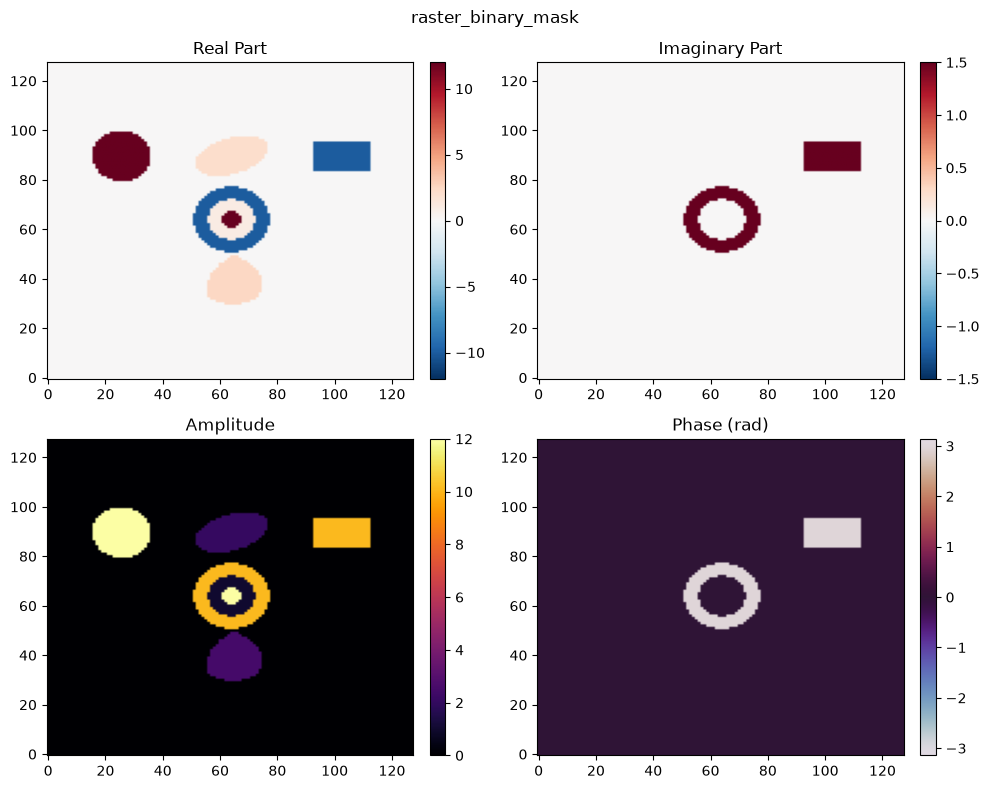

In [3]:
api = "raster_media_binary_mask"
t0 = time.perf_counter()
raw = getattr(rast, api)(lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = as_cplx_field(raw)
assert field.shape == (N, N)
visualizer.display_complex_field(field, "raster_binary_mask")


## Binary mask (overlap)

`raster_media_binary_mask_overlap`


[timing] raster_media_binary_mask_overlap: 27.89 ms


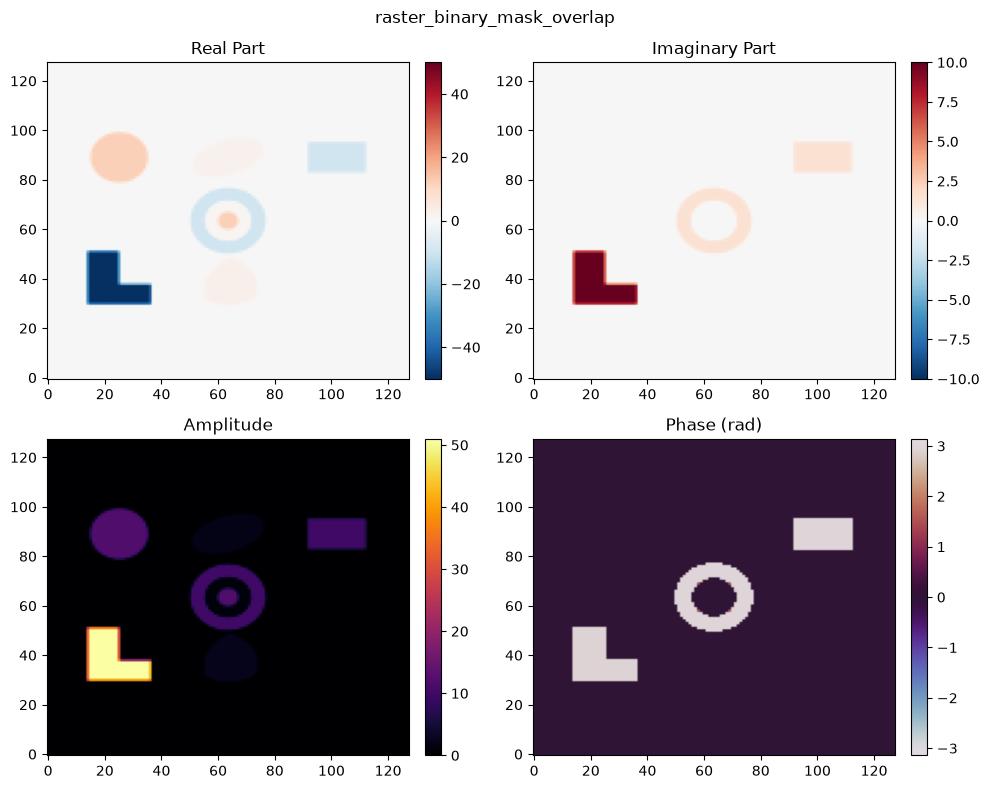

In [4]:
api = "raster_media_binary_mask_overlap"
t0 = time.perf_counter()
raw = getattr(rast, api)(lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = as_cplx_field(raw)
assert field.shape == (N, N)
visualizer.display_complex_field(field, "raster_binary_mask_overlap")


## Thin mask

`raster_media_thin_mask`（manhattan 友好的 rect / L-poly 会有非平凡结构）。


[timing] raster_media_thin_mask: 4.23 ms


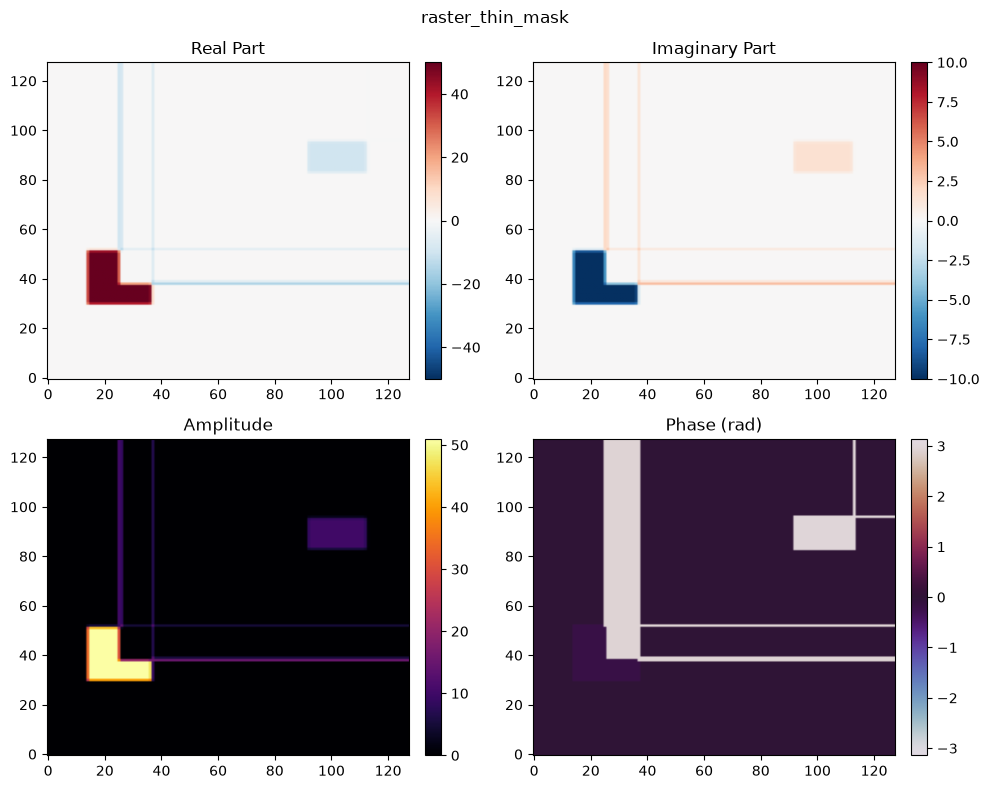

In [5]:
api = "raster_media_thin_mask"
t0 = time.perf_counter()
raw = getattr(rast, api)(lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = as_cplx_field(raw)
assert field.shape == (N, N)
assert np.max(np.abs(field - field.flat[0])) > 1e-6
visualizer.display_complex_field(field, "raster_thin_mask")


## Fourier transform → IFFT

`raster_media_fourier_transform` 得到 corner-zero 频谱，再 IFFT 到实空间显示（与测试一致）。


[timing] raster_media_fourier_transform: 10848.95 ms


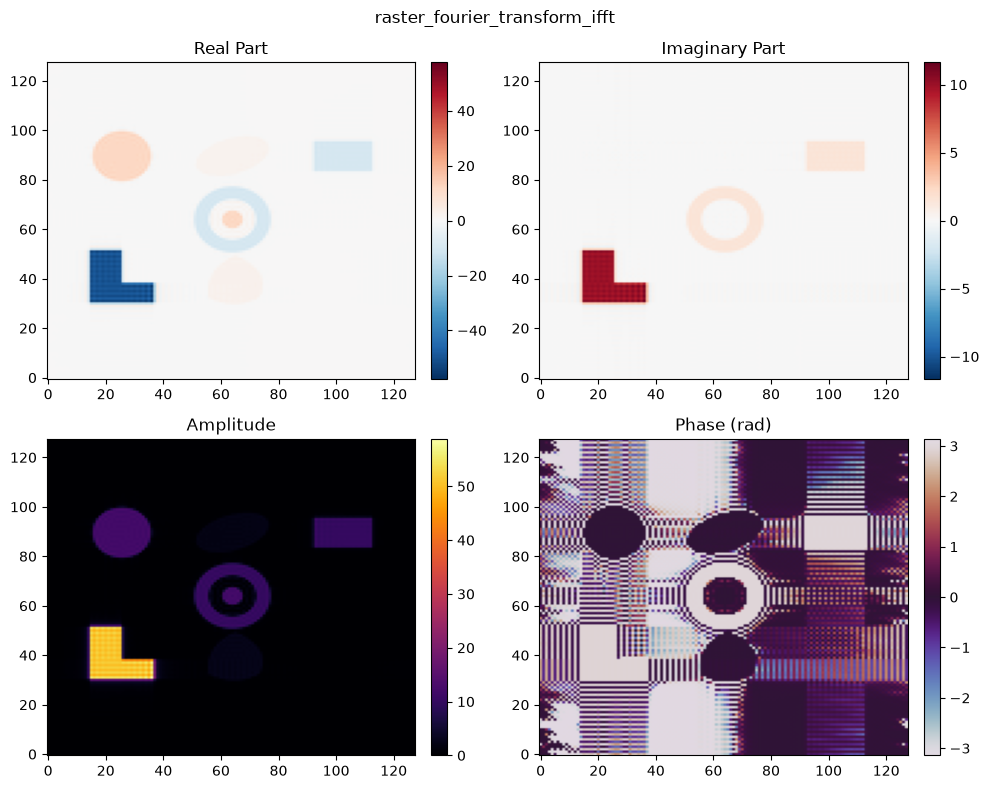

In [6]:
api = "raster_media_fourier_transform"
t0 = time.perf_counter()
raw = getattr(rast, api)(lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
field = fourier_ifft(raw)
assert field.shape == (N, N)
visualizer.display_complex_field(field, "raster_fourier_transform_ifft")


## Kottke ε tensor

`raster_media_kottke`：五个分量 εxx/εxy/εyx/εyy/εzz 的幅值与相位。


[timing] raster_media_kottke: 5288.45 ms


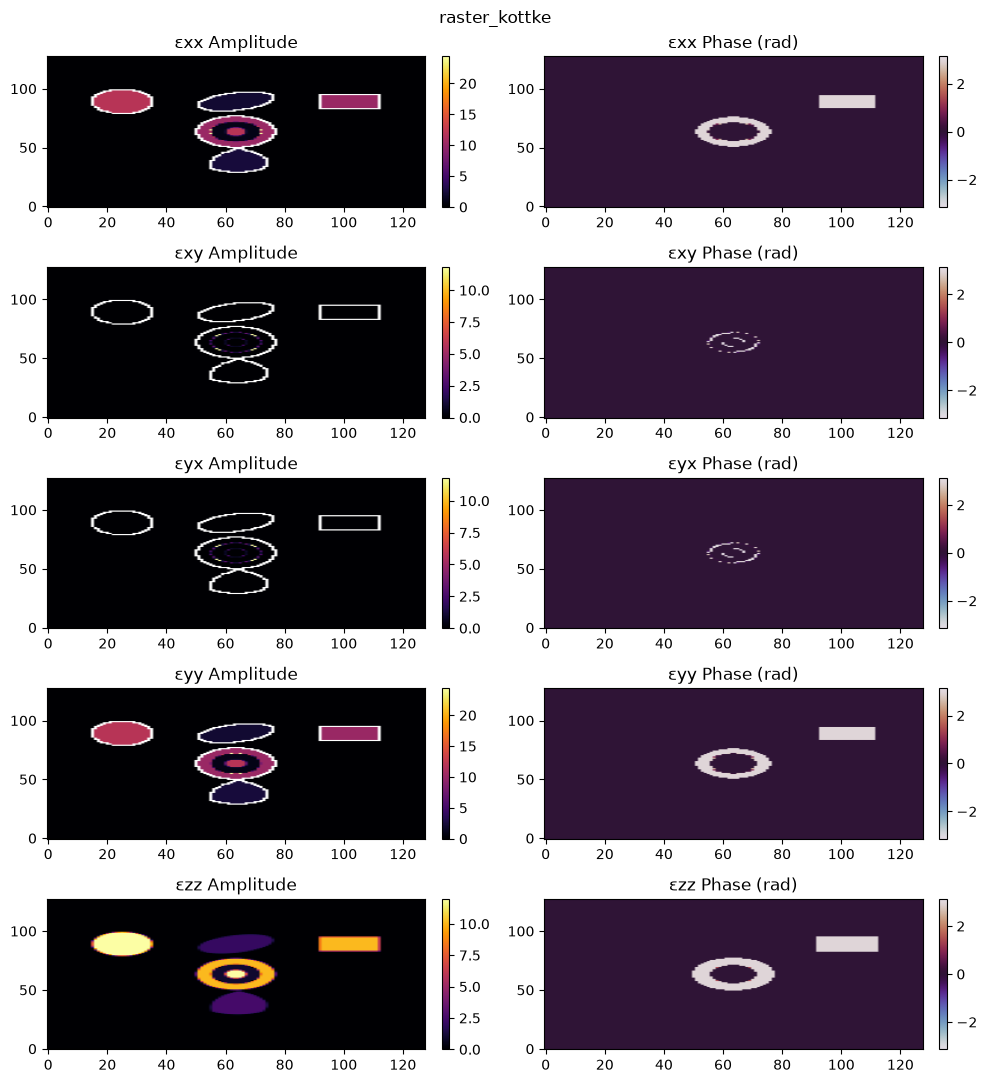

In [7]:
api = "raster_media_kottke"
t0 = time.perf_counter()
raw = getattr(rast, api)(lyr, grid, WL)
print(f"[timing] {api}: {(time.perf_counter() - t0) * 1e3:.2f} ms")
assert len(raw) == N * N
tensor = kottke_tensor(raw)
assert tensor.shape == (N, N, len(KOTTKE_COMPS))
display_kottke_amp_phase(tensor, "raster_kottke")
